# GNN for Airline Fare Prediction

Edge-level regression on an airport route graph. Airports are **nodes**, routes are directed **edges**, and the target is `MARKET_FARE`. A Graph Neural Network aggregates hub-neighborhood context (competition, connectivity) that a simple distance regression cannot capture.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GINEConv, GATConv

sns.set_theme(style='whitegrid')
BLUE = '#4393c3'
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

PyTorch 2.12.0.dev20260321+cu128  |  CUDA: True


## 1. Data Loading & Filtering

Load the clean dataset, apply quality filters, then draw a stratified 10% sample (by ORIGIN airport) to keep the graph connected while fitting in memory. Raw individual ticket rows are kept — no pre-aggregation, since the GNN learns to aggregate information via message passing.

In [33]:
DATA_PATH = '../../data/clean_data/T_DB1B_MARKET_CLEAN.csv'
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Raw:  {len(df):,} rows")

# Quality filters:
#   BULK_FARE == 0              — exclude employee/contract fares
#   MKT_GEO_TYPE == 2           — domestic contiguous US only
df = df[
    (df['BULK_FARE'] == 0) &
    (df['MKT_GEO_TYPE'] == 2)
].copy()
print(f"After filters: {len(df):,} rows ({len(df)/32_520_273:.1%} retained)")

# 10% stratified sample by ORIGIN — keeps graph connected (all hub airports represented)
# No aggregation: raw ticket rows preserve fare variance that GNN/GAT learn from
agg = df.groupby('ORIGIN').sample(frac=0.01, random_state=42).reset_index(drop=True)
print(f"Sample: {len(agg):,} rows")
agg.head()

Raw:  25,072,315 rows
After filters: 23,941,830 rows (73.6% retained)
Sample: 239,405 rows


,YEAR,QUARTER,ORIGIN_AIRPORT_ID,ORIGIN,DEST_AIRPORT_ID,DEST,REPORTING_CARRIER,TICKET_CARRIER,OPERATING_CARRIER,BULK_FARE,PASSENGERS,MARKET_FARE,MARKET_DISTANCE,NONSTOP_MILES,MKT_GEO_TYPE,ORIGIN_LAT,ORIGIN_LON,DEST_LAT,DEST_LON
0,2025,2,10135,ABE,13577,MYR,G4,G4,G4,0.0,2.0,88.00,518.0,518.0,2,40.6521,-75.440804,33.679699,-78.928299
1,2025,2,10135,ABE,12266,IAH,UA,UA,99,0.0,1.0,470.50,1580.0,1339.0,2,40.6521,-75.440804,29.984400,-95.341400
2,2024,4,10135,ABE,13930,ORD,G7,UA,G7,0.0,1.0,212.00,655.0,655.0,2,40.6521,-75.440804,41.978600,-87.904800
3,2025,2,10135,ABE,10397,ATL,9E,DL,9E,0.0,1.0,474.00,692.0,692.0,2,40.6521,-75.440804,33.636700,-84.428101
4,2024,3,10135,ABE,11298,DFW,AA,99,99,0.0,1.0,160.96,1358.0,1307.0,2,40.6521,-75.440804,32.896801,-97.038002


In [34]:
#print out format of data
print(agg.dtypes)


YEAR                   int64
QUARTER                int64
ORIGIN_AIRPORT_ID      int64
ORIGIN                object
DEST_AIRPORT_ID        int64
DEST                  object
REPORTING_CARRIER     object
TICKET_CARRIER        object
OPERATING_CARRIER     object
BULK_FARE            float64
PASSENGERS           float64
MARKET_FARE          float64
MARKET_DISTANCE      float64
NONSTOP_MILES        float64
MKT_GEO_TYPE           int64
ORIGIN_LAT           float64
ORIGIN_LON           float64
DEST_LAT             float64
DEST_LON             float64
dtype: object


## 2. Feature Engineering

**Node features** (per airport, computed from train set only to avoid leakage): out-degree, mean departing fare. Lat/lon excluded — airport identity is already captured by ORIGIN/DEST dummies in the Ridge/MLP and by graph topology in the GNN/GAT.

**Edge features** (per raw ticket row): log distance, cyclic quarter encoding (sin/cos so Q4→Q1 wraps correctly), passengers, carrier as a learned embedding.

**Target**: `log(MARKET_FARE)` — log-transform stabilises MSE training on the right-skewed fare distribution.

In [35]:
# ── Carrier consolidation (before split so train_df gets the column) ─────────
agg['carrier'] = agg['REPORTING_CARRIER'].replace({'9E':'DL','OH':'AA','MQ':'AA','QX':'AS','C5':'UA'})
carriers       = agg['carrier'].unique()
carrier_to_idx = {c: i for i, c in enumerate(carriers)}
num_carriers   = len(carriers)
print(f"Unique carriers: {num_carriers}")
# ── Temporal split masks ──────────────────────────────────────────────────────
train_mask = (agg['YEAR'] == 2024)                               # Q3 + Q4 2024
val_mask   = (agg['YEAR'] == 2025) & (agg['QUARTER'] == 1)      # Q1 2025
test_mask  = (agg['YEAR'] == 2025) & (agg['QUARTER'] == 2)      # Q2 2025
train_df   = agg[train_mask]
print(f"Train: {train_mask.sum():,}  Val: {val_mask.sum():,}  Test: {test_mask.sum():,}")

# ── Airport index ─────────────────────────────────────────────────────────────
all_airports   = pd.unique(pd.concat([agg['ORIGIN'], agg['DEST']]))
airport_to_idx = {a: i for i, a in enumerate(all_airports)}
num_airports   = len(all_airports)
print(f"Unique airports: {num_airports}")


Unique carriers: 20
Train: 124,115  Val: 52,810  Test: 62,480
Unique airports: 389


In [36]:
# ── Node features (fit on train only) ────────────────────────────────────────
in_degree_map  = train_df.groupby("DEST")["ORIGIN"].nunique().rename("in_degree")
node_stats = (
    train_df.groupby("ORIGIN")
    .agg(
        degree       = ("DEST",        "nunique"),
        mean_fare    = ("MARKET_FARE",  "mean"),
        num_carriers = ("REPORTING_CARRIER", "nunique"),
        std_fare     = ("MARKET_FARE",  "std"),
    )
    .join(in_degree_map, how="left")
    .fillna(0)
    .reindex(all_airports, fill_value=0)
)
node_scaler    = StandardScaler()
node_feat_cols = ["degree", "in_degree", "mean_fare", "num_carriers", "std_fare"]
node_features  = torch.tensor(
    node_scaler.fit_transform(node_stats[node_feat_cols].values),
    dtype=torch.float
)
print(f"Node feature matrix: {node_features.shape}")


Node feature matrix: torch.Size([389, 5])


In [37]:
# ── Carrier index for GNN embedding ─────────────────────────────────────────
carriers       = agg['carrier'].unique()
carrier_to_idx = {c: i for i, c in enumerate(carriers)}
num_carriers   = len(carriers)
print(f"Unique consolidated carriers: {num_carriers}")
print(sorted(carriers))


Unique consolidated carriers: 20
['3M', 'AA', 'AS', 'B6', 'DL', 'F9', 'G4', 'G7', 'HA', 'MX', 'NK', 'OO', 'PT', 'SY', 'UA', 'WN', 'XP', 'YV', 'YX', 'ZW']


In [38]:
# ── Macro data (quarterly) ────────────────────────────────────────────────────
jet_fuel = pd.read_csv('../../data/rawdata/JET_FUEL.csv').rename(columns={'year': 'YEAR', 'quarter': 'QUARTER'})
real_dpi = pd.read_csv('../../data/rawdata/REAL_DPI.csv').rename(columns={'year': 'YEAR', 'quarter': 'QUARTER'})
unrate   = pd.read_csv('../../data/rawdata/UNRATE.csv').rename(columns={'year': 'YEAR', 'quarter': 'QUARTER'})
air_cpi  = pd.read_csv('../../data/rawdata/AIR_CPI.csv').rename(columns={'year': 'YEAR', 'quarter': 'QUARTER', 'AIR_CPI_1982-1984=100': 'AIR_CPI'})

agg = agg.merge(jet_fuel, on=['YEAR', 'QUARTER'], how='left')
agg = agg.merge(real_dpi, on=['YEAR', 'QUARTER'], how='left')
agg = agg.merge(unrate,   on=['YEAR', 'QUARTER'], how='left')
agg = agg.merge(air_cpi,  on=['YEAR', 'QUARTER'], how='left')
print("Macro data merged.")

Macro data merged.


In [39]:
# ── P6 Form 41 carrier operating costs (quarterly) ───────────────────────────
p6 = pd.concat([
    pd.read_csv('../../data/rawdata/P6_2024_Q3.csv'),
    pd.read_csv('../../data/rawdata/P6_2024_Q4.csv'),
    pd.read_csv('../../data/rawdata/P6_2025_Q1.csv'),
    pd.read_csv('../../data/rawdata/P6_2025_Q2.csv'),
], ignore_index=True)
for col in ['SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS']:
    p6[col] = p6[col] * 1000
p6_agg = (
    p6.groupby(['UNIQUE_CARRIER', 'YEAR', 'QUARTER'])
    [['SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS']]
    .sum().reset_index()
)
agg = agg.merge(
    p6_agg,
    left_on =['carrier', 'YEAR', 'QUARTER'],
    right_on=['UNIQUE_CARRIER',  'YEAR', 'QUARTER'],
    how='left'
).drop(columns='UNIQUE_CARRIER')
agg[['SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS']] = \
    agg[['SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS']].fillna(0)
print("P6 cost data merged.")

P6 cost data merged.


In [40]:
# ── Route HHI and carrier market share ───────────────────────────────────────
route_pax = (
    agg.groupby(['ORIGIN', 'DEST', 'YEAR', 'QUARTER', 'carrier'])['PASSENGERS']
    .sum().reset_index(name='carrier_pax')
)
route_total = (
    route_pax.groupby(['ORIGIN', 'DEST', 'YEAR', 'QUARTER'])['carrier_pax']
    .sum().reset_index(name='total_pax')
)
route_pax = route_pax.merge(route_total, on=['ORIGIN', 'DEST', 'YEAR', 'QUARTER'])
route_pax['carrier_route_share'] = route_pax['carrier_pax'] / route_pax['total_pax']
route_pax['share_sq']            = route_pax['carrier_route_share'] ** 2
hhi = (
    route_pax.groupby(['ORIGIN', 'DEST', 'YEAR', 'QUARTER'])['share_sq']
    .sum().reset_index(name='route_hhi')
)
carrier_share = route_pax[['ORIGIN', 'DEST', 'YEAR', 'QUARTER', 'carrier', 'carrier_route_share']]
agg = agg.merge(hhi,           on=['ORIGIN', 'DEST', 'YEAR', 'QUARTER'],                        how='left')
agg = agg.merge(carrier_share, on=['ORIGIN', 'DEST', 'YEAR', 'QUARTER', 'carrier'],             how='left')
print("HHI and carrier share computed.")

HHI and carrier share computed.


In [41]:
# ── Base feature engineering ──────────────────────────────────────────────────
agg['log_distance']           = np.log1p(agg['MARKET_DISTANCE'])
agg['detour_ratio']           = agg['MARKET_DISTANCE'] / agg['NONSTOP_MILES']
agg['is_short_haul']          = (agg['MARKET_DISTANCE'] < 500).astype(int)
agg['route_total_passengers'] = agg.groupby(['ORIGIN','DEST','YEAR','QUARTER'])['PASSENGERS'].transform('sum')

LCC = {'WN', 'B6', 'NK', 'F9', 'G4', 'SY', 'VX'}
agg['is_lcc']        = agg['carrier'].isin(LCC).astype(int)
agg['route_has_lcc'] = agg.groupby(['ORIGIN','DEST','YEAR','QUARTER'])['is_lcc'].transform('max')

agg['carrier_idx']             = agg['carrier'].map(carrier_to_idx)
agg['log_fare']                = np.log(agg['MARKET_FARE'])
agg['src_idx']                 = agg['ORIGIN'].map(airport_to_idx)
agg['dst_idx']                 = agg['DEST'].map(airport_to_idx)
agg['origin_num_destinations'] = agg.groupby(['ORIGIN','YEAR','QUARTER'])['DEST'].transform('nunique')
agg['dest_num_destinations']   = agg.groupby(['DEST','YEAR','QUARTER'])['ORIGIN'].transform('nunique')
print("Base features computed.")

Base features computed.


In [42]:
# ── Interaction features ──────────────────────────────────────────────────────
# Route x carrier mean fare (train only — analog of margin x product_group)
route_carrier_mean = (
    agg[train_mask]
    .groupby(['ORIGIN', 'DEST', 'carrier'])['log_fare']
    .mean()
    .rename('route_carrier_mean_logfare')
)
agg = agg.join(route_carrier_mean, on=['ORIGIN', 'DEST', 'carrier'])
agg['route_carrier_mean_logfare'] = agg['route_carrier_mean_logfare'].fillna(
    agg.loc[train_mask, 'route_carrier_mean_logfare'].mean()
)

# Income elasticity by distance tier
agg['DPI_x_short_haul'] = agg['2017_dollars_DPI'] * agg['is_short_haul']
agg['DPI_x_long_haul']  = agg['2017_dollars_DPI'] * (1 - agg['is_short_haul'])

# Fuel burden scales with route distance
agg['fuel_x_distance'] = agg['JET_FUEL_DPG'] * agg['log_distance']
print("Interaction features computed.")

Interaction features computed.


In [43]:
# ── Edge feature matrix (scaler fit on train only) ────────────────────────────
edge_feat_cols = [
    'log_distance', 'PASSENGERS',
    'detour_ratio', 'is_short_haul', 'route_total_passengers',
    'JET_FUEL_DPG', '2017_dollars_DPI', 'UNRATE_pct', 'AIR_CPI',
    'SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS',
    'route_hhi', 'carrier_route_share', 'route_has_lcc',
]
# fill NaN before scaling (route_hhi / carrier_route_share can be NaN from left joins)
for col in edge_feat_cols:
    agg[col] = agg[col].fillna(agg.loc[train_mask, col].median())

edge_scaler = StandardScaler()
edge_scaler.fit(agg.loc[train_mask, edge_feat_cols].values)
edge_feats = edge_scaler.transform(agg[edge_feat_cols].values)
print(f"Edge feature matrix: {edge_feats.shape}")
print("NaN in edge_feats:", np.isnan(edge_feats).sum())


Edge feature matrix: (239405, 16)
NaN in edge_feats: 0


In [44]:
# route absorbed fixed effect: mean log_fare per route computed on training set only
route_mean_fare = agg[train_mask].groupby(['ORIGIN', 'DEST'])['log_fare'].mean().rename('route_mean_logfare')
agg = agg.join(route_mean_fare, on=['ORIGIN', 'DEST'])
agg['route_mean_logfare'] = agg['route_mean_logfare'].fillna(agg.loc[train_mask, 'route_mean_logfare'].mean())

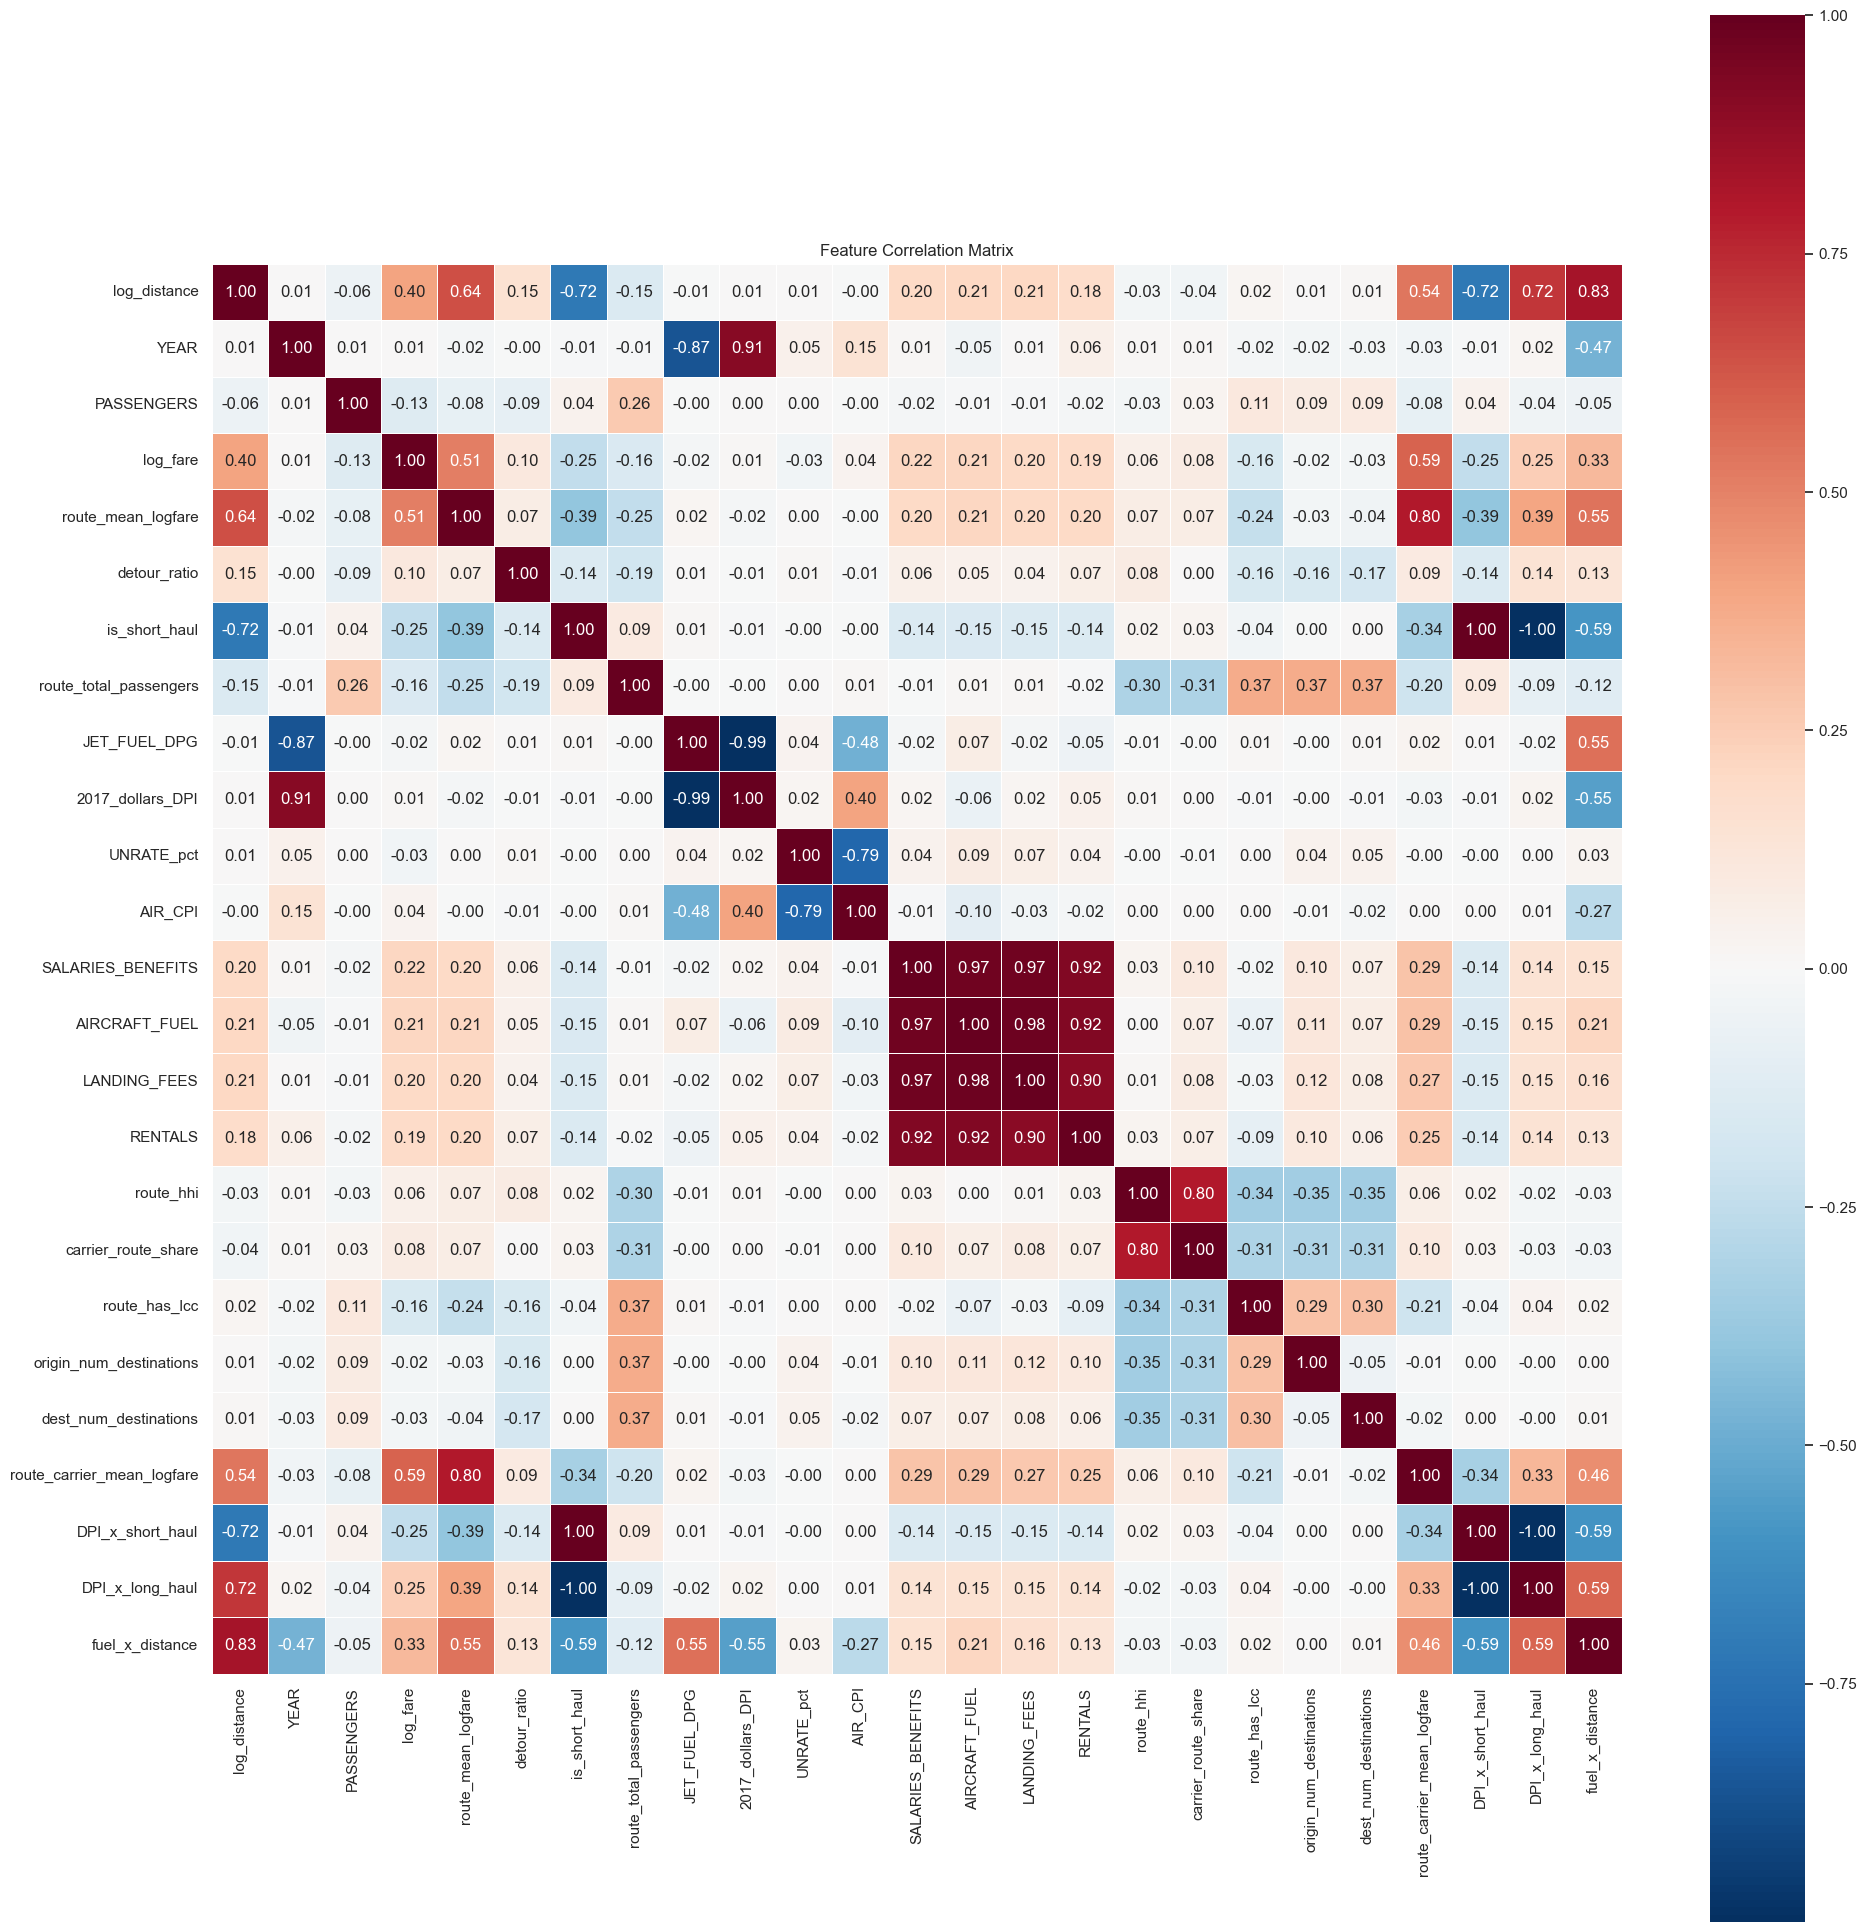

,log_distance,YEAR,PASSENGERS,log_fare,route_mean_logfare,detour_ratio,is_short_haul,route_total_passengers,JET_FUEL_DPG,2017_dollars_DPI,...,RENTALS,route_hhi,carrier_route_share,route_has_lcc,origin_num_destinations,dest_num_destinations,route_carrier_mean_logfare,DPI_x_short_haul,DPI_x_long_haul,fuel_x_distance
log_distance,1.000000,0.007496,-0.061466,0.402563,0.643674,0.150063,-0.717857,-0.146712,-0.006007,0.006618,...,0.182879,-0.025482,-0.035264,0.016313,7.449404e-03,0.009706,0.538094,-7.178347e-01,0.717760,0.830045
YEAR,0.007496,1.000000,0.005618,0.007802,-0.021533,-0.004008,-0.011525,-0.010880,-0.866279,0.910387,...,0.055073,0.012663,0.008239,-0.017788,-2.398664e-02,-0.030948,-0.032645,-9.237886e-03,0.023459,-0.475000
PASSENGERS,-0.061466,0.005618,1.000000,-0.129036,-0.084404,-0.090463,0.042886,0.260015,-0.003311,0.003985,...,-0.019463,-0.026338,0.029340,0.106094,8.554133e-02,0.088507,-0.078511,4.289810e-02,-0.042825,-0.053077
log_fare,0.402563,0.007802,-0.129036,1.000000,0.514984,0.104216,-0.249418,-0.155546,-0.016185,0.013606,...,0.192490,0.057295,0.080101,-0.163275,-2.433783e-02,-0.030234,0.589922,-2.493535e-01,0.249504,0.327117
route_mean_logfare,0.643674,-0.021533,-0.084404,0.514984,1.000000,0.070977,-0.393887,-0.248989,0.016155,-0.017278,...,0.200639,0.074081,0.073592,-0.240539,-2.715814e-02,-0.039402,0.803901,-3.938478e-01,0.393480,0.546492
detour_ratio,0.150063,-0.004008,-0.090463,0.104216,0.070977,1.000000,-0.143689,-0.189646,0.006276,-0.005559,...,0.068806,0.078750,0.000230,-0.156995,-1.622192e-01,-0.172919,0.086259,-1.436807e-01,0.143558,0.128776
is_short_haul,-0.717857,-0.011525,0.042886,-0.249418,-0.393887,-0.143689,1.000000,0.086572,0.010053,-0.010610,...,-0.141414,0.024060,0.030375,-0.037396,2.514152e-05,0.001627,-0.335288,9.999804e-01,-0.999898,-0.592777
route_total_passengers,-0.146712,-0.010880,0.260015,-0.155546,-0.248989,-0.189646,0.086572,1.000000,-0.001598,-0.000574,...,-0.015284,-0.304710,-0.309280,0.371135,3.746714e-01,0.374613,-0.203480,8.652709e-02,-0.086515,-0.123332
JET_FUEL_DPG,-0.006007,-0.866279,-0.003311,-0.016185,0.016155,0.006276,0.010053,-0.001598,1.000000,-0.994384,...,-0.047848,-0.006873,-0.004309,0.010591,-2.921665e-03,0.011259,0.024716,7.554245e-03,-0.023088,0.550561
2017_dollars_DPI,0.006618,0.910387,0.003985,0.013606,-0.017278,-0.005559,-0.010610,-0.000574,-0.994384,1.000000,...,0.051954,0.007913,0.004841,-0.012077,-1.756248e-04,-0.013203,-0.026848,-8.098115e-03,0.023720,-0.546934


In [45]:
num_cols = [
    'log_distance', 'YEAR', 'PASSENGERS', 'log_fare', 'route_mean_logfare',
    'detour_ratio', 'is_short_haul', 'route_total_passengers',
    'JET_FUEL_DPG', '2017_dollars_DPI', 'UNRATE_pct', 'AIR_CPI',
    'SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS',
    'route_hhi', 'carrier_route_share', 'route_has_lcc', 'origin_num_destinations', 'dest_num_destinations',
    'route_carrier_mean_logfare',
'DPI_x_short_haul', 'DPI_x_long_haul',
'fuel_x_distance'
]
corr = agg[num_cols].corr()

fig, ax = plt.subplots(figsize=(20,20))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()
agg[num_cols].corr()

## 3. Graph Construction (PyTorch Geometric)

One global graph — all quarters share the same node set (airports). Quarter and carrier are encoded as edge features, so a single `Data` object holds the full dataset with per-edge targets and split masks.

In [46]:
edge_index  = torch.tensor(agg[['src_idx', 'dst_idx']].values.T, dtype=torch.long)
edge_attr   = torch.tensor(edge_feats, dtype=torch.float)
carrier_ids = torch.tensor(agg['carrier_idx'].values, dtype=torch.long)
y           = torch.tensor(agg['log_fare'].values, dtype=torch.float)

train_idx = torch.where(torch.tensor(train_mask.values))[0]
val_idx   = torch.where(torch.tensor(val_mask.values))[0]
test_idx  = torch.where(torch.tensor(test_mask.values))[0]

data = Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr, y=y)
data.carrier_ids = carrier_ids

print(f"Graph — nodes: {data.num_nodes:,}  |  edges: {data.num_edges:,}")
print(f"Node feat dim: {data.num_node_features}  |  Edge feat dim: {data.num_edge_features}")
print(f"Train edges: {len(train_idx):,}  Val: {len(val_idx):,}  Test: {len(test_idx):,}")

Graph — nodes: 389  |  edges: 239,405
Node feat dim: 5  |  Edge feat dim: 16
Train edges: 124,115  Val: 52,810  Test: 62,480


## 4. Baseline — Enhanced Ridge Regression

Ridge regression with a rich fixed-effects feature set: log-distance, cyclic quarter, year, one-hot ORIGIN (400 airports), DEST (400 airports), TICKET_CARRIER, and REPORTING_CARRIER. This is a strong benchmark — it captures most route-level fixed effects that a simple linear model can recover. The GNN must beat this to demonstrate that graph neighborhood context adds genuine value beyond what dummy variables already encode.

In [47]:
num_cols = [
    'route_mean_logfare',           # route fixed effect
    'route_carrier_mean_logfare',   # route x carrier interaction
    'log_distance',
    'fuel_x_distance',             # fuel burden scales with distance
    'SALARIES_BENEFITS',
    'AIRCRAFT_FUEL',
    'LANDING_FEES',
    'RENTALS',
    'is_short_haul',
    'DPI_x_short_haul',            # income elasticity: short-haul
    'DPI_x_long_haul',             # income elasticity: long-haul
    'route_has_lcc',
    'PASSENGERS',
    'route_total_passengers',
    'detour_ratio',
    'route_hhi',
    'carrier_route_share',
    'origin_num_destinations',
    'dest_num_destinations',
    'AIR_CPI',
    'UNRATE_pct',
    '2017_dollars_DPI',
    'JET_FUEL_DPG',
    'YEAR',
]

In [48]:
print(num_cols)

['route_mean_logfare', 'route_carrier_mean_logfare', 'log_distance', 'fuel_x_distance', 'SALARIES_BENEFITS', 'AIRCRAFT_FUEL', 'LANDING_FEES', 'RENTALS', 'is_short_haul', 'DPI_x_short_haul', 'DPI_x_long_haul', 'route_has_lcc', 'PASSENGERS', 'route_total_passengers', 'detour_ratio', 'route_hhi', 'carrier_route_share', 'origin_num_destinations', 'dest_num_destinations', 'AIR_CPI', 'UNRATE_pct', '2017_dollars_DPI', 'JET_FUEL_DPG', 'YEAR']


In [49]:
# ── eval_dollars + preprocessor setup (shared by Ridge, forward/backward, MLP) ─
def eval_dollars(y_true_log, y_pred_log):
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    r2   = r2_score(y_true_log, y_pred_log)
    return rmse, mae, r2

cat_cols = ['carrier', 'QUARTER', 'ORIGIN']   # ORIGIN, DEST dropped — already captured by route features
X_cols   = num_cols + cat_cols
X        = agg[X_cols].copy()
y_np     = agg['log_fare'].values

X_train, y_train = X[train_mask], y_np[train_mask]
X_val,   y_val   = X[val_mask],   y_np[val_mask]
X_test,  y_test  = X[test_mask],  y_np[test_mask]

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), cat_cols),
])
print(f"X_train: {X_train.shape}  X_val: {X_val.shape}  X_test: {X_test.shape}")

X_train: (124115, 27)  X_val: (52810, 27)  X_test: (62480, 27)


In [50]:
def aic_linear(y_true, y_pred, k):
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    return n * np.log(rss / n) + 2 * k

# ── Transform once ────────────────────────────────────────────────────────────
X_train_t = preprocessor.fit_transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

ohe_start = len(num_cols)
ohe_idx   = list(range(ohe_start, X_train_t.shape[1]))

def fit_eval(cols, X_tr, y_tr, X_v, y_v):
    lr   = Ridge().fit(X_tr[:, cols], y_tr)
    pred = lr.predict(X_v[:, cols])
    return aic_linear(y_v, pred, len(cols)), lr, pred

# ══════════════════════════════════════════════════════════════════════════════
# STEPWISE SELECTION (FORWARD + BACKWARD AT EACH STEP)
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("STEPWISE SELECTION (Bidirectional)")
print("=" * 60)
selected_sw  = []
remaining_sw = list(range(len(num_cols)))
best_aic_sw  = np.inf

for step in range(2 * len(num_cols)):
    improved = False

    # Forward step
    aic_fwd = {}
    for idx in remaining_sw:
        cols = ohe_idx + selected_sw + [idx]
        aic_fwd[idx], _, _ = fit_eval(cols, X_train_t, y_train, X_val_t, y_val)
    if aic_fwd:
        best_add = min(aic_fwd, key=aic_fwd.get)
        if aic_fwd[best_add] < best_aic_sw:
            best_aic_sw = aic_fwd[best_add]
            selected_sw.append(best_add)
            remaining_sw.remove(best_add)
            print(f"  Step {step+1} [+]: +{num_cols[best_add]:38s}  AIC={best_aic_sw:.1f}")
            improved = True

    # Backward step
    aic_bwd = {}
    for idx in selected_sw:
        cols = ohe_idx + [i for i in selected_sw if i != idx]
        aic_bwd[idx], _, _ = fit_eval(cols, X_train_t, y_train, X_val_t, y_val)
    if aic_bwd:
        best_rem = min(aic_bwd, key=aic_bwd.get)
        if aic_bwd[best_rem] < best_aic_sw:
            best_aic_sw = aic_bwd[best_rem]
            selected_sw.remove(best_rem)
            remaining_sw.append(best_rem)
            print(f"  Step {step+1} [-]: -{num_cols[best_rem]:38s}  AIC={best_aic_sw:.1f}")
            improved = True

    if not improved:
        print(f"  Step {step+1}: No improvement — stopping.")
        break

final_cols_sw = ohe_idx + selected_sw
sw_model = Ridge().fit(X_train_t[:, final_cols_sw], y_train)
bl_val  = sw_model.predict(X_val_t[:, final_cols_sw])
bl_test = sw_model.predict(X_test_t[:, final_cols_sw])
rmse_v, mae_v, r2_v = eval_dollars(y_val,  bl_val)
rmse_t, mae_t, r2_t = eval_dollars(y_test, bl_test)
print(f"\nStepwise Val  — RMSE: ${rmse_v:.1f}  MAE: ${mae_v:.1f}  R²: {r2_v:.3f}")
print(f"Stepwise Test — RMSE: ${rmse_t:.1f}  MAE: ${mae_t:.1f}  R²: {r2_t:.3f}")
print(f"Selected: {[num_cols[i] for i in selected_sw]}")

c:\Users\Administrator\anaconda3\envs\dsan\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Administrator\anaconda3\envs\dsan\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


STEPWISE SELECTION (Bidirectional)
  Step 1 [+]: +log_distance                            AIC=-92269.6
  Step 2 [+]: +UNRATE_pct                              AIC=-92836.9
  Step 3 [+]: +route_total_passengers                  AIC=-93140.5
  Step 4 [+]: +PASSENGERS                              AIC=-93301.4
  Step 5 [+]: +carrier_route_share                     AIC=-93484.5
  Step 6 [+]: +origin_num_destinations                 AIC=-93545.5
  Step 7 [+]: +is_short_haul                           AIC=-93590.8
  Step 8 [+]: +dest_num_destinations                   AIC=-93606.7
  Step 9 [+]: +route_has_lcc                           AIC=-93634.5
  Step 10 [+]: +AIRCRAFT_FUEL                           AIC=-93647.2
  Step 11 [+]: +RENTALS                                 AIC=-93686.6
  Step 12 [+]: +route_hhi                               AIC=-93693.7
  Step 13 [+]: +detour_ratio                            AIC=-93696.9
  Step 14: No improvement — stopping.

Stepwise Val  — RMSE: $110.0  MAE: $84

In [51]:
import statsmodels.api as sm

# ── Get feature names ─────────────────────────────────────────────────────────
ohe_feature_names = preprocessor.named_transformers_['cat'] \
                                 .get_feature_names_out(cat_cols).tolist()
all_feature_names = num_cols + ohe_feature_names
selected_names    = [all_feature_names[i] for i in final_cols_sw]

# ── Fit OLS on the same columns stepwise selected ─────────────────────────────
X_ols = sm.add_constant(X_train_t[:, final_cols_sw].toarray()
        if hasattr(X_train_t[:, final_cols_sw], 'toarray')
        else X_train_t[:, final_cols_sw])

ols_model = sm.OLS(y_train, X_ols).fit()

# ── Build clean regression table ─────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'  : ['const'] + selected_names,
    'Coef'     : ols_model.params,
    'Std Err'  : ols_model.bse,
    't-stat'   : ols_model.tvalues,
    'p-value'  : ols_model.pvalues,
    'Sig'      : pd.cut(ols_model.pvalues,
                        bins=[-1, 0.001, 0.01, 0.05, 0.1, 1.0],
                        labels=['***', '**', '*', '.', ''])
}).sort_values('p-value').reset_index(drop=True)

coef_df.index += 1

print("\n── OLS Regression Table (stepwise-selected features) ───────────────")
print(coef_df.to_string())
print("\n  Significance: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1")
print(f"\n  R²={ols_model.rsquared:.4f}  Adj-R²={ols_model.rsquared_adj:.4f}")
print(f"  F-stat={ols_model.fvalue:.1f}  p={ols_model.f_pvalue:.2e}")
print(f"  AIC={ols_model.aic:.1f}  BIC={ols_model.bic:.1f}")


── OLS Regression Table (stepwise-selected features) ───────────────
                     Feature          Coef       Std Err      t-stat        p-value  Sig
1               log_distance  2.137617e-01  1.796138e-03  119.011854   0.000000e+00  ***
2                 PASSENGERS -4.043565e-02  1.214410e-03  -33.296544  5.139806e-242  ***
3              is_short_haul  3.733811e-02  1.726886e-03   21.621644  1.749473e-103  ***
4        carrier_route_share  3.233778e-02  2.064538e-03   15.663451   3.039354e-55  ***
5                 carrier_G7  5.456499e-01  4.967367e-02   10.984691   4.665236e-28  ***
6     route_total_passengers -1.725493e-02  1.596128e-03  -10.810491   3.157584e-27  ***
7                 carrier_YV  4.178439e-01  4.830653e-02    8.649844   5.217210e-18  ***
8                 carrier_PT  4.141749e-01  4.838392e-02    8.560177   1.139565e-17  ***
9                 carrier_OO  3.992024e-01  4.696984e-02    8.499122   1.931098e-17  ***
10                carrier_YX  3.623005e-

In [52]:
print(f"Total features in model: {len(final_cols_sw)}")
print(f"Non-zero coefficients: {np.sum(sw_model.coef_ != 0)}")
print(f"Selected numeric features: {[num_cols[i] for i in selected_sw]}")

Total features in model: 399
Non-zero coefficients: 399
Selected numeric features: ['log_distance', 'UNRATE_pct', 'route_total_passengers', 'PASSENGERS', 'carrier_route_share', 'origin_num_destinations', 'is_short_haul', 'dest_num_destinations', 'route_has_lcc', 'AIRCRAFT_FUEL', 'RENTALS', 'route_hhi', 'detour_ratio']


In [53]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

y = agg["log_fare"].values.reshape(-1, 1)

models = {
    "Distance only (OLS)":   agg[["log_distance"]].values,
    "HHI only (OLS)":        agg[["route_hhi"]].values,
    "Distance + HHI (OLS)":  agg[["log_distance", "route_hhi"]].values,
}

results = {}
for name, X in models.items():
    lr = LinearRegression().fit(X, y)
    r2 = r2_score(y, lr.predict(X))
    results[name] = round(r2, 4)
    print(f"{name:30s}  R² = {r2:.4f}")

# Ridge on same data (no train/test split)
for name, X in [("Distance only (Ridge)",  agg[["log_distance"]].values),
                ("HHI only (Ridge)",        agg[["route_hhi"]].values),
                ("Distance + HHI (Ridge)",  agg[["log_distance", "route_hhi"]].values)]:
    rr = Ridge().fit(X, y)
    r2 = r2_score(y, rr.predict(X))
    results[name] = round(r2, 4)
    print(f"{name:30s}  R² = {r2:.4f}")

Distance only (OLS)             R² = 0.1621
HHI only (OLS)                  R² = 0.0033
Distance + HHI (OLS)            R² = 0.1666
Distance only (Ridge)           R² = 0.1621
HHI only (Ridge)                R² = 0.0033
Distance + HHI (Ridge)          R² = 0.1666


In [54]:
# checking for data shape after OHE
X_train.shape, X_val.shape, X_test.shape

((124115, 27), (52810, 27), (62480, 27))

In [55]:
for col in ['TICKET_CARRIER', 'REPORTING_CARRIER', 'ORIGIN', 'DEST']:
    print(f"{col}: {agg[col].nunique()}")

TICKET_CARRIER: 18
REPORTING_CARRIER: 25
ORIGIN: 386
DEST: 377


In [56]:
393+397+25+23+9

847

## 5. MLP — Multilayer Perceptron

Same feature set as the enhanced Ridge (same `ColumnTransformer` preprocessing), but non-linear. A 3-hidden-layer feedforward network with BatchNorm and Dropout. Isolates whether non-linear combinations of route fixed effects help — before introducing graph structure.

Architecture: `Input (~870) → 256 → 128 → 64 → 1`

c:\Users\Administrator\anaconda3\envs\dsan\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Administrator\anaconda3\envs\dsan\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


MLP input dim: 410
MLP(
  (net): Sequential(
    (0): Linear(in_features=410, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable parameters: 63,425
Epoch  10  train: 1.8787  val: 0.7772  lr: 1.00e-03
Epoch  20  train: 1.2574  val: 0.2441  lr: 1.00e-03
Epoch  30  train: 1.1438  val: 0.2639  lr: 1.00e-03
Epoch  40  train: 0.9009  val: 0.1831  lr: 1.00e-03
E

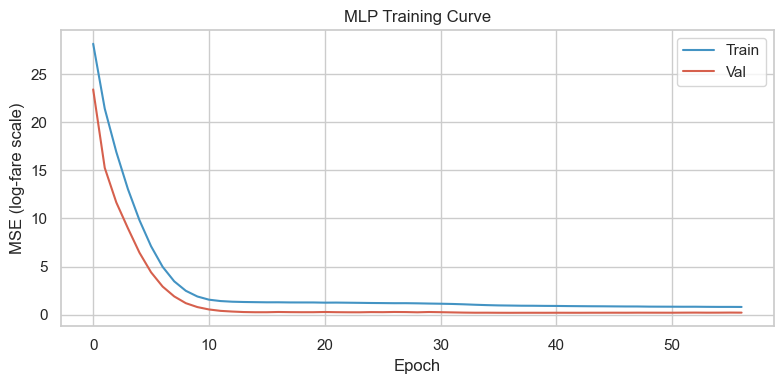

MLP     Val  — RMSE: $116.8  MAE: $88.3  R²: 0.218
MLP     Test — RMSE: $112.4  MAE: $84.9  R²: 0.207


In [57]:
# ── Preprocess with the same pipeline as Ridge ────────────────────────────────
# Reuse the fitted preprocessor so features are identical (OHE + numeric including PASSENGERS)
X_train_np = preprocessor.transform(X_train).astype(np.float32)
X_val_np   = preprocessor.transform(X_val).astype(np.float32)
X_test_np  = preprocessor.transform(X_test).astype(np.float32)
input_dim  = X_train_np.shape[1]
print(f"MLP input dim: {input_dim}")

X_tr_t  = torch.tensor(X_train_np)
X_va_t  = torch.tensor(X_val_np)
X_te_t  = torch.tensor(X_test_np)
y_tr_t  = torch.tensor(y_train.astype(np.float32))
y_va_t  = torch.tensor(y_val.astype(np.float32))

# ── Model ─────────────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, in_dim, hidden=(128, 64, 32), dropout=0.3):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

mlp_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
mlp_model  = MLP(input_dim).to(mlp_device)
n_params   = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(mlp_model)
print(f"Trainable parameters: {n_params:,}")

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE = 4096
PATIENCE   = 20
optimizer  = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
dataset    = torch.utils.data.TensorDataset(X_tr_t, y_tr_t)
loader     = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

X_va_d = X_va_t.to(mlp_device)
y_va_d = y_va_t.to(mlp_device)

mlp_train_losses, mlp_val_losses = [], []
best_mlp_val, best_mlp_state, mlp_patience_ctr = float('inf'), None, 0

for epoch in range(1, 150):
    mlp_model.train()
    epoch_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(mlp_device), yb.to(mlp_device)
        optimizer.zero_grad()
        loss = F.mse_loss(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(dataset)

    mlp_model.eval()
    with torch.no_grad():
        val_loss = F.mse_loss(mlp_model(X_va_d), y_va_d).item()

    scheduler.step(val_loss)
    mlp_train_losses.append(epoch_loss)
    mlp_val_losses.append(val_loss)

    if val_loss < best_mlp_val:
        best_mlp_val   = val_loss
        best_mlp_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}
        mlp_patience_ctr = 0
    else:
        mlp_patience_ctr += 1
        if mlp_patience_ctr >= PATIENCE:
            print(f"Early stop at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train: {epoch_loss:.4f}  val: {val_loss:.4f}  lr: {optimizer.param_groups[0]['lr']:.2e}")

mlp_model.load_state_dict(best_mlp_state)
print(f"Best MLP val loss: {best_mlp_val:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_train_losses, label='Train', color='#4393c3')
ax.plot(mlp_val_losses,   label='Val',   color='#d6604d')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log-fare scale)')
ax.set_title('MLP Training Curve'); ax.legend()
plt.tight_layout(); plt.show()

# ── Eval ──────────────────────────────────────────────────────────────────────
mlp_model.eval()
with torch.no_grad():
    mlp_val_pred  = mlp_model(X_va_t.to(mlp_device)).cpu().numpy()
    mlp_test_pred = mlp_model(X_te_t.to(mlp_device)).cpu().numpy()

mlp_rmse_v, mlp_mae_v, mlp_r2_v = eval_dollars(y_val,  mlp_val_pred)
mlp_rmse_t, mlp_mae_t, mlp_r2_t = eval_dollars(y_test, mlp_test_pred)
print(f"MLP     Val  — RMSE: ${mlp_rmse_v:.1f}  MAE: ${mlp_mae_v:.1f}  R²: {mlp_r2_v:.3f}")
print(f"MLP     Test — RMSE: ${mlp_rmse_t:.1f}  MAE: ${mlp_mae_t:.1f}  R²: {mlp_r2_t:.3f}")


## 6. GNN Model — EdgeGNN

Architecture:
1. **NodeEncoder**: linear projection of node features → hidden dimension
2. **2× SAGEConv**: message-passing layers that aggregate hub-neighborhood context
3. **EdgeDecoder**: MLP on `[src_emb ‖ dst_emb ‖ edge_feats ‖ carrier_emb]` → predicted log-fare

Carrier is a learned `nn.Embedding` (8-dim) rather than one-hot, which handles rare carriers and captures latent pricing similarities. Unlike Ridge and MLP, the GNN sees the full graph topology — each airport's embedding reflects its hub connections, competition, and pricing neighbourhood.

In [58]:
class EdgeGNN(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, num_carriers,
                 hidden_dim=256, carrier_emb_dim=8, dropout=0.1):
        super().__init__()
        self.carrier_emb = nn.Embedding(num_carriers, carrier_emb_dim)
        self.node_enc    = nn.Linear(node_feat_dim, hidden_dim)

        mlp1 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                              nn.Linear(hidden_dim, hidden_dim))
        mlp2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                              nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(mlp1, edge_dim=edge_feat_dim)
        self.conv2 = GINEConv(mlp2, edge_dim=edge_feat_dim)

        dec_in = 2 * hidden_dim + edge_feat_dim + carrier_emb_dim
        self.decoder = nn.Sequential(
            nn.Linear(dec_in, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x, edge_index, edge_attr, carrier_ids):
        h = F.relu(self.node_enc(x))
        h = F.relu(self.conv1(h, edge_index, edge_attr=edge_attr))
        h = F.relu(self.conv2(h, edge_index, edge_attr=edge_attr))

        src, dst = edge_index
        carrier_e = self.carrier_emb(carrier_ids)
        edge_in   = torch.cat([h[src], h[dst], edge_attr, carrier_e], dim=-1)
        return self.decoder(edge_in).squeeze(-1)


model = EdgeGNN(
    node_feat_dim  = node_features.shape[1],
    edge_feat_dim  = edge_attr.shape[1],
    num_carriers   = num_carriers,
    hidden_dim     = 256,
)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {n_params:,}")

EdgeGNN(
  (carrier_emb): Embedding(20, 8)
  (node_enc): Linear(in_features=5, out_features=256, bias=True)
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  ))
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  ))
  (decoder): Sequential(
    (0): Linear(in_features=536, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 427,553


## 7. GNN Training

Full-graph training (all edges fit in memory). Adam with weight decay, MSE loss on log-fare, early stopping on validation loss with patience=100.

Training on: cuda
Epoch  10  train: 2292051.5000  val: 14515865.0000  lr: 1.00e-03
Epoch  20  train: 159741.2500  val: 117846.7500  lr: 1.00e-03
Epoch  30  train: 1483.5869  val: 1930.1616  lr: 1.00e-03
Epoch  40  train: 177.0002  val: 146.6921  lr: 1.00e-03
Epoch  50  train: 50.0716  val: 106.3926  lr: 1.00e-03
Epoch  60  train: 9.1307  val: 18.2268  lr: 1.00e-03
Epoch  70  train: 5.3357  val: 7.8478  lr: 1.00e-03
Epoch  80  train: 4.2541  val: 4.0666  lr: 1.00e-03
Epoch  90  train: 4.9380  val: 3.7762  lr: 1.00e-03
Epoch 100  train: 4.4545  val: 3.7435  lr: 1.00e-03
Epoch 110  train: 3.8321  val: 4.7351  lr: 1.00e-03
Epoch 120  train: 16.1310  val: 16.5221  lr: 1.00e-03
Epoch 130  train: 11.7122  val: 9.8985  lr: 1.00e-03
Epoch 140  train: 3.9107  val: 3.5420  lr: 5.00e-04
Epoch 150  train: 3.5608  val: 3.7815  lr: 5.00e-04
Epoch 160  train: 3.7404  val: 3.2278  lr: 5.00e-04
Epoch 170  train: 3.6728  val: 3.0572  lr: 5.00e-04
Epoch 180  train: 3.0866  val: 3.3425  lr: 5.00e-04
Epoch 

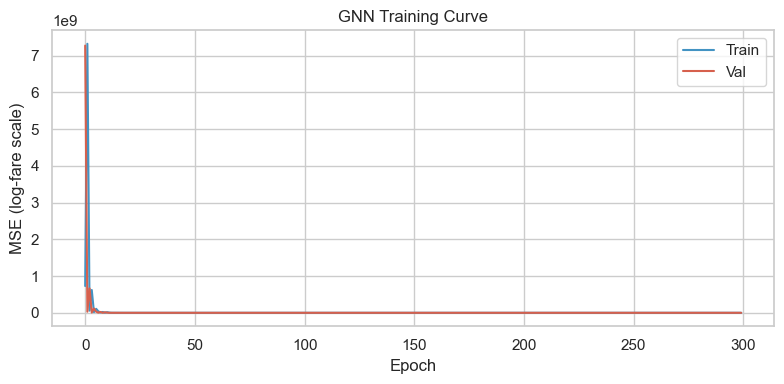

In [59]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on: {device}")

model = EdgeGNN(
    node_feat_dim = node_features.shape[1],
    edge_feat_dim = edge_attr.shape[1],
    num_carriers  = num_carriers,
    hidden_dim    = 256,
).to(device)

x_d    = data.x.to(device)
ei_d   = data.edge_index.to(device)
ea_d   = data.edge_attr.to(device)
cids_d = data.carrier_ids.to(device)
y_d    = data.y.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=20, min_lr=1e-5
)

train_losses, val_losses = [], []
best_val_loss = float('inf')
patience, patience_ctr = 100, 0
best_state = None

for epoch in range(1, 301):
    model.train()
    optimizer.zero_grad()
    pred = model(x_d, ei_d, ea_d, cids_d)
    loss = F.mse_loss(pred[train_idx], y_d[train_idx])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_all = model(x_d, ei_d, ea_d, cids_d)
        val_loss = F.mse_loss(pred_all[val_idx], y_d[val_idx]).item()

    train_losses.append(loss.item())
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"Early stop at epoch {epoch}")
            break

    scheduler.step(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train: {loss.item():.4f}  val: {val_loss:.4f}  lr: {optimizer.param_groups[0]['lr']:.2e}")

model.load_state_dict(best_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train', color='#4393c3')
ax.plot(val_losses,   label='Val',   color='#d6604d')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (log-fare scale)')
ax.set_title('GNN Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 8. GAT Model — EdgeGAT

Graph Attention Network variant. Identical EdgeDecoder to the GNN, but replaces SAGEConv with **GATConv** — attention weights are computed per-neighbor using edge features (`edge_dim`), so the model learns *which* connections matter most for fare prediction rather than averaging uniformly.

Architecture:
1. **NodeEncoder**: linear projection → hidden dim
2. **2× GATConv** (4 heads → 1 head): attention-weighted message passing with edge features
3. **EdgeDecoder**: same MLP on `[src_emb ‖ dst_emb ‖ edge_feats ‖ carrier_emb]` → log-fare

EdgeGAT(
  (carrier_emb): Embedding(20, 8)
  (node_enc): Linear(in_features=5, out_features=256, bias=True)
  (conv1): GATConv(256, 64, heads=4)
  (conv2): GATConv(256, 256, heads=1)
  (decoder): Sequential(
    (0): Linear(in_features=536, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 296,993
Epoch  10  train: 22.7675  val: 16.3869  lr: 1.00e-03
Epoch  20  train: 1.2494  val: 0.3269  lr: 1.00e-03
Epoch  30  train: 0.4701  val: 0.2880  lr: 1.00e-03
Epoch  40  train: 0.2591  val: 0.2209  lr: 1.00e-03
Epoch  50  train: 0.3245  val: 0.3523  lr: 1.00e-03
Epoch  60  train: 0.2240  val: 0.3149  lr: 1.00e-03
Epoch  70  train: 0.2548  val: 0.1834  lr: 1.00e-03
Epoch  80  train: 0.2393  val: 0.1847  lr: 1.00e-03
Epoch  90  train: 0.2192  val: 0.1751  lr: 5.00e-04
Epoch 100  train: 0.2200  val: 0

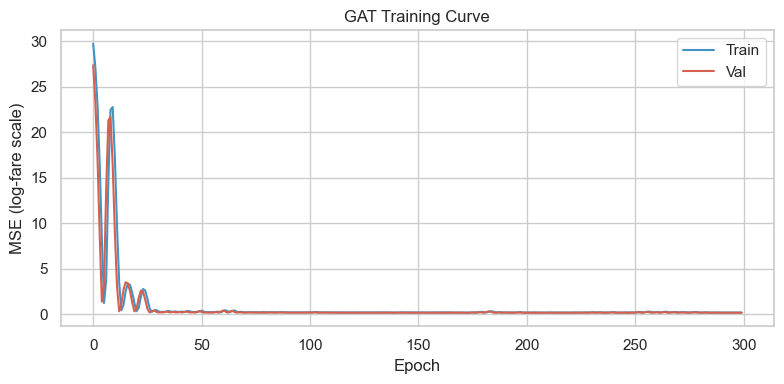

In [60]:
# ── Model ─────────────────────────────────────────────────────────────────────
class EdgeGAT(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, num_carriers,
                 hidden_dim=256, heads=4, carrier_emb_dim=8, dropout=0.1):
        super().__init__()
        self.carrier_emb = nn.Embedding(num_carriers, carrier_emb_dim)
        self.node_enc    = nn.Linear(node_feat_dim, hidden_dim)
        # GATConv with edge_dim feeds edge features into the attention coefficient
        self.conv1 = GATConv(hidden_dim, hidden_dim // heads, heads=heads,
                             edge_dim=edge_feat_dim, dropout=dropout)
        self.conv2 = GATConv(hidden_dim, hidden_dim, heads=1,
                             edge_dim=edge_feat_dim, dropout=dropout)

        dec_in = 2 * hidden_dim + edge_feat_dim + carrier_emb_dim
        self.decoder = nn.Sequential(
            nn.Linear(dec_in, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),     nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x, edge_index, edge_attr, carrier_ids):
        h = F.relu(self.node_enc(x))
        h = F.relu(self.conv1(h, edge_index, edge_attr=edge_attr))
        h = F.relu(self.conv2(h, edge_index, edge_attr=edge_attr))
        src, dst  = edge_index
        carrier_e = self.carrier_emb(carrier_ids)
        edge_in   = torch.cat([h[src], h[dst], edge_attr, carrier_e], dim=-1)
        return self.decoder(edge_in).squeeze(-1)


gat_model = EdgeGAT(
    node_feat_dim = node_features.shape[1],
    edge_feat_dim = edge_attr.shape[1],
    num_carriers  = num_carriers,
    hidden_dim    = 256,
).to(device)
n_params = sum(p.numel() for p in gat_model.parameters() if p.requires_grad)
print(gat_model)
print(f"\nTrainable parameters: {n_params:,}")

# ── Training ──────────────────────────────────────────────────────────────────
optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_gat = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_gat, mode='min', factor=0.5, patience=20, min_lr=1e-5
)

gat_train_losses, gat_val_losses = [], []
best_gat_val, best_gat_state, gat_patience_ctr = float('inf'), None, 0
PATIENCE_GAT = 100

for epoch in range(1, 301):
    gat_model.train()
    optimizer_gat.zero_grad()
    pred = gat_model(x_d, ei_d, ea_d, cids_d)
    loss = F.mse_loss(pred[train_idx], y_d[train_idx])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(gat_model.parameters(), 1.0)
    optimizer_gat.step()

    gat_model.eval()
    with torch.no_grad():
        pred_all = gat_model(x_d, ei_d, ea_d, cids_d)
        val_loss = F.mse_loss(pred_all[val_idx], y_d[val_idx]).item()

    gat_train_losses.append(loss.item())
    gat_val_losses.append(val_loss)

    if val_loss < best_gat_val:
        best_gat_val   = val_loss
        best_gat_state = {k: v.clone() for k, v in gat_model.state_dict().items()}
        gat_patience_ctr = 0
    else:
        gat_patience_ctr += 1
        if gat_patience_ctr >= PATIENCE_GAT:
            print(f"Early stop at epoch {epoch}")
            break

    scheduler_gat.step(val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  train: {loss.item():.4f}  val: {val_loss:.4f}  lr: {optimizer_gat.param_groups[0]['lr']:.2e}")

gat_model.load_state_dict(best_gat_state)
print(f"\nBest GAT val loss: {best_gat_val:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gat_train_losses, label='Train', color='#4393c3')
ax.plot(gat_val_losses,   label='Val',   color='#d6604d')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log-fare scale)')
ax.set_title('GAT Training Curve'); ax.legend()
plt.tight_layout(); plt.show()

## 9. Residual GNN — MLP + Graph Correction

The standalone GNN struggles when the signal ceiling is low (R²≈0.3): it has to re-learn all route fixed effects from scratch using only graph structure. **Residual learning** sidesteps this by letting the MLP handle the bulk of the prediction and training the GNN to correct only what the MLP got wrong.

Architecture:
1. MLP prediction frozen as the base estimate
2. **ResidualGNN**: same GINEConv stack, but decoder input includes the MLP logit
3. **Conservative gate** `sigmoid(g)` initialised at `g=-1.5` (≈0.18) — graph correction starts near-zero and grows only if it genuinely reduces loss
4. Final prediction: `mlp_pred + sigmoid(gate) * gnn_correction`

In [62]:
# ── MLP predictions on ALL rows (train+val+test) to use as base ───────────────
mlp_model.eval()
X_all_np = preprocessor.transform(agg[X_cols]).astype(np.float32)
with torch.no_grad():
    mlp_all_pred = mlp_model(torch.tensor(X_all_np).to(mlp_device)).cpu().numpy()

mlp_pred_t = torch.tensor(mlp_all_pred, dtype=torch.float).to(device)
print(f"MLP all-predictions shape: {mlp_pred_t.shape}")
print(f"NaN in mlp_pred_t: {torch.isnan(mlp_pred_t).sum().item()}")

# ── ResidualGNN: GNN predicts correction on top of MLP ────────────────────────
class ResidualGNN(nn.Module):
    def __init__(self, node_feat_dim, edge_feat_dim, num_carriers,
                 hidden_dim=256, carrier_emb_dim=8, dropout=0.1):
        super().__init__()
        # Conservative gate: sigmoid(-1.5) ≈ 0.18 — correction starts near-zero
        self.gate = nn.Parameter(torch.tensor(-1.5))

        self.carrier_emb = nn.Embedding(num_carriers, carrier_emb_dim)
        self.node_enc    = nn.Linear(node_feat_dim, hidden_dim)

        mlp1 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                              nn.Linear(hidden_dim, hidden_dim))
        mlp2 = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                              nn.Linear(hidden_dim, hidden_dim))
        self.conv1 = GINEConv(mlp1, edge_dim=edge_feat_dim)
        self.conv2 = GINEConv(mlp2, edge_dim=edge_feat_dim)

        # decoder: src_emb + dst_emb + edge_attr + carrier_emb + mlp_pred scalar
        dec_in = 2 * hidden_dim + edge_feat_dim + carrier_emb_dim + 1
        self.decoder = nn.Sequential(
            nn.Linear(dec_in, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x, edge_index, edge_attr, carrier_ids, mlp_pred):
        h = F.relu(self.node_enc(x))
        h = F.relu(self.conv1(h, edge_index, edge_attr=edge_attr))
        h = F.relu(self.conv2(h, edge_index, edge_attr=edge_attr))

        src, dst  = edge_index
        carrier_e = self.carrier_emb(carrier_ids)
        edge_in   = torch.cat([h[src], h[dst], edge_attr, carrier_e,
                                mlp_pred.unsqueeze(-1)], dim=-1)
        correction = self.decoder(edge_in).squeeze(-1)
        return mlp_pred + torch.sigmoid(self.gate) * correction


res_model = ResidualGNN(
    node_feat_dim = node_features.shape[1],
    edge_feat_dim = edge_attr.shape[1],
    num_carriers  = num_carriers,
    hidden_dim    = 256,
).to(device)
n_params = sum(p.numel() for p in res_model.parameters() if p.requires_grad)
print(res_model)
print(f"\nTrainable parameters: {n_params:,}")
print(f"Initial gate: sigmoid({res_model.gate.item():.2f}) = {torch.sigmoid(res_model.gate).item():.3f}")

c:\Users\Administrator\anaconda3\envs\dsan\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


MLP all-predictions shape: torch.Size([239405])
NaN in mlp_pred_t: 0
ResidualGNN(
  (carrier_emb): Embedding(20, 8)
  (node_enc): Linear(in_features=5, out_features=256, bias=True)
  (conv1): GINEConv(nn=Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  ))
  (conv2): GINEConv(nn=Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
  ))
  (decoder): Sequential(
    (0): Linear(in_features=537, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=1, bias=True)
  )
)

Trainable parameters: 427,810
Initial gate: sigmoid(-1.50) = 0.182


Epoch  10  train: 728622.0625  val: 224820.7656  gate: 0.181  lr: 1.00e-03
Epoch  20  train: 10724.4082  val: 4039.9595  gate: 0.180  lr: 1.00e-03
Epoch  30  train: 84.3191  val: 114.7398  gate: 0.179  lr: 1.00e-03
Epoch  40  train: 14.6297  val: 0.4688  gate: 0.179  lr: 1.00e-03
Epoch  50  train: 0.5720  val: 0.4786  gate: 0.178  lr: 1.00e-03
Epoch  60  train: 0.1325  val: 0.1910  gate: 0.177  lr: 1.00e-03
Epoch  70  train: 0.1367  val: 0.1817  gate: 0.177  lr: 1.00e-03
Epoch  80  train: 0.1282  val: 0.2092  gate: 0.177  lr: 1.00e-03
Epoch  90  train: 0.1318  val: 0.1839  gate: 0.177  lr: 5.00e-04
Epoch 100  train: 0.1278  val: 0.1914  gate: 0.177  lr: 5.00e-04
Epoch 110  train: 0.1270  val: 0.1907  gate: 0.176  lr: 5.00e-04
Epoch 120  train: 0.1271  val: 0.1925  gate: 0.177  lr: 2.50e-04
Epoch 130  train: 0.1266  val: 0.1892  gate: 0.177  lr: 2.50e-04
Epoch 140  train: 0.1264  val: 0.1903  gate: 0.177  lr: 1.25e-04
Epoch 150  train: 0.1263  val: 0.1908  gate: 0.177  lr: 1.25e-04
Epoc

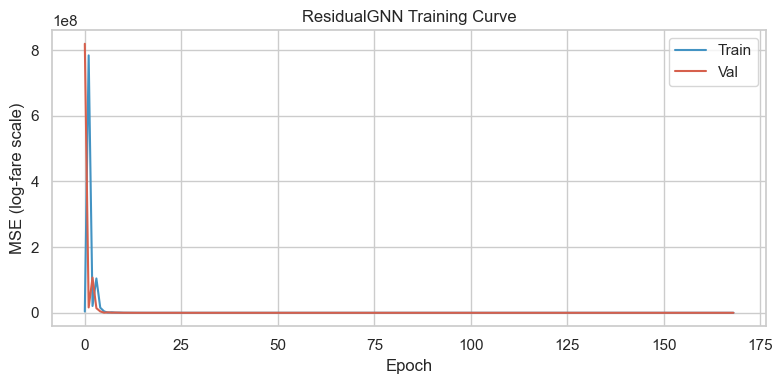

In [63]:
optimizer_res = torch.optim.Adam(res_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler_res = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_res, mode='min', factor=0.5, patience=20, min_lr=1e-5
)

res_train_losses, res_val_losses = [], []
best_res_val, best_res_state, res_patience_ctr = float('inf'), None, 0
PATIENCE_RES = 100

for epoch in range(1, 301):
    res_model.train()
    optimizer_res.zero_grad()
    pred = res_model(x_d, ei_d, ea_d, cids_d, mlp_pred_t)
    loss = F.mse_loss(pred[train_idx], y_d[train_idx])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(res_model.parameters(), 1.0)
    optimizer_res.step()

    res_model.eval()
    with torch.no_grad():
        pred_all = res_model(x_d, ei_d, ea_d, cids_d, mlp_pred_t)
        val_loss = F.mse_loss(pred_all[val_idx], y_d[val_idx]).item()

    res_train_losses.append(loss.item())
    res_val_losses.append(val_loss)

    if val_loss < best_res_val:
        best_res_val   = val_loss
        best_res_state = {k: v.clone() for k, v in res_model.state_dict().items()}
        res_patience_ctr = 0
    else:
        res_patience_ctr += 1
        if res_patience_ctr >= PATIENCE_RES:
            print(f"Early stop at epoch {epoch}")
            break

    scheduler_res.step(val_loss)

    if epoch % 10 == 0:
        gate_val = torch.sigmoid(res_model.gate).item()
        print(f"Epoch {epoch:3d}  train: {loss.item():.4f}  val: {val_loss:.4f}  "
              f"gate: {gate_val:.3f}  lr: {optimizer_res.param_groups[0]['lr']:.2e}")

res_model.load_state_dict(best_res_state)
print(f"\nBest ResidualGNN val loss: {best_res_val:.4f}")
print(f"Final gate value: sigmoid({res_model.gate.item():.3f}) = {torch.sigmoid(res_model.gate).item():.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res_train_losses, label='Train', color='#4393c3')
ax.plot(res_val_losses,   label='Val',   color='#d6604d')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (log-fare scale)')
ax.set_title('ResidualGNN Training Curve'); ax.legend()
plt.tight_layout(); plt.show()

## 10. Model Comparison

All five models evaluated on the held-out test set (2025 Q2). Metrics in original dollar scale for interpretability. Expected ordering: ResidualGNN ≥ GAT ≥ GNN ≥ MLP ≥ Ridge+.

Model           Split   RMSE ($)   MAE ($)      R²
-------------------------------------------------------------
Ridge+          Val       110.0      84.6   0.279
Ridge+          Test      106.7      80.8   0.287
-------------------------------------------------------------
MLP             Val       116.8      88.3   0.218
MLP             Test      112.4      84.9   0.207
-------------------------------------------------------------
GNN             Val       278.0     199.0  -6.378
GNN             Test      282.7     200.3  -6.578
-------------------------------------------------------------
GAT             Val       109.7      84.4   0.286
GAT             Test      105.5      81.1   0.283
-------------------------------------------------------------
ResidualGNN     Val       115.4      88.1   0.220
ResidualGNN     Test      111.5      85.1   0.202
-------------------------------------------------------------


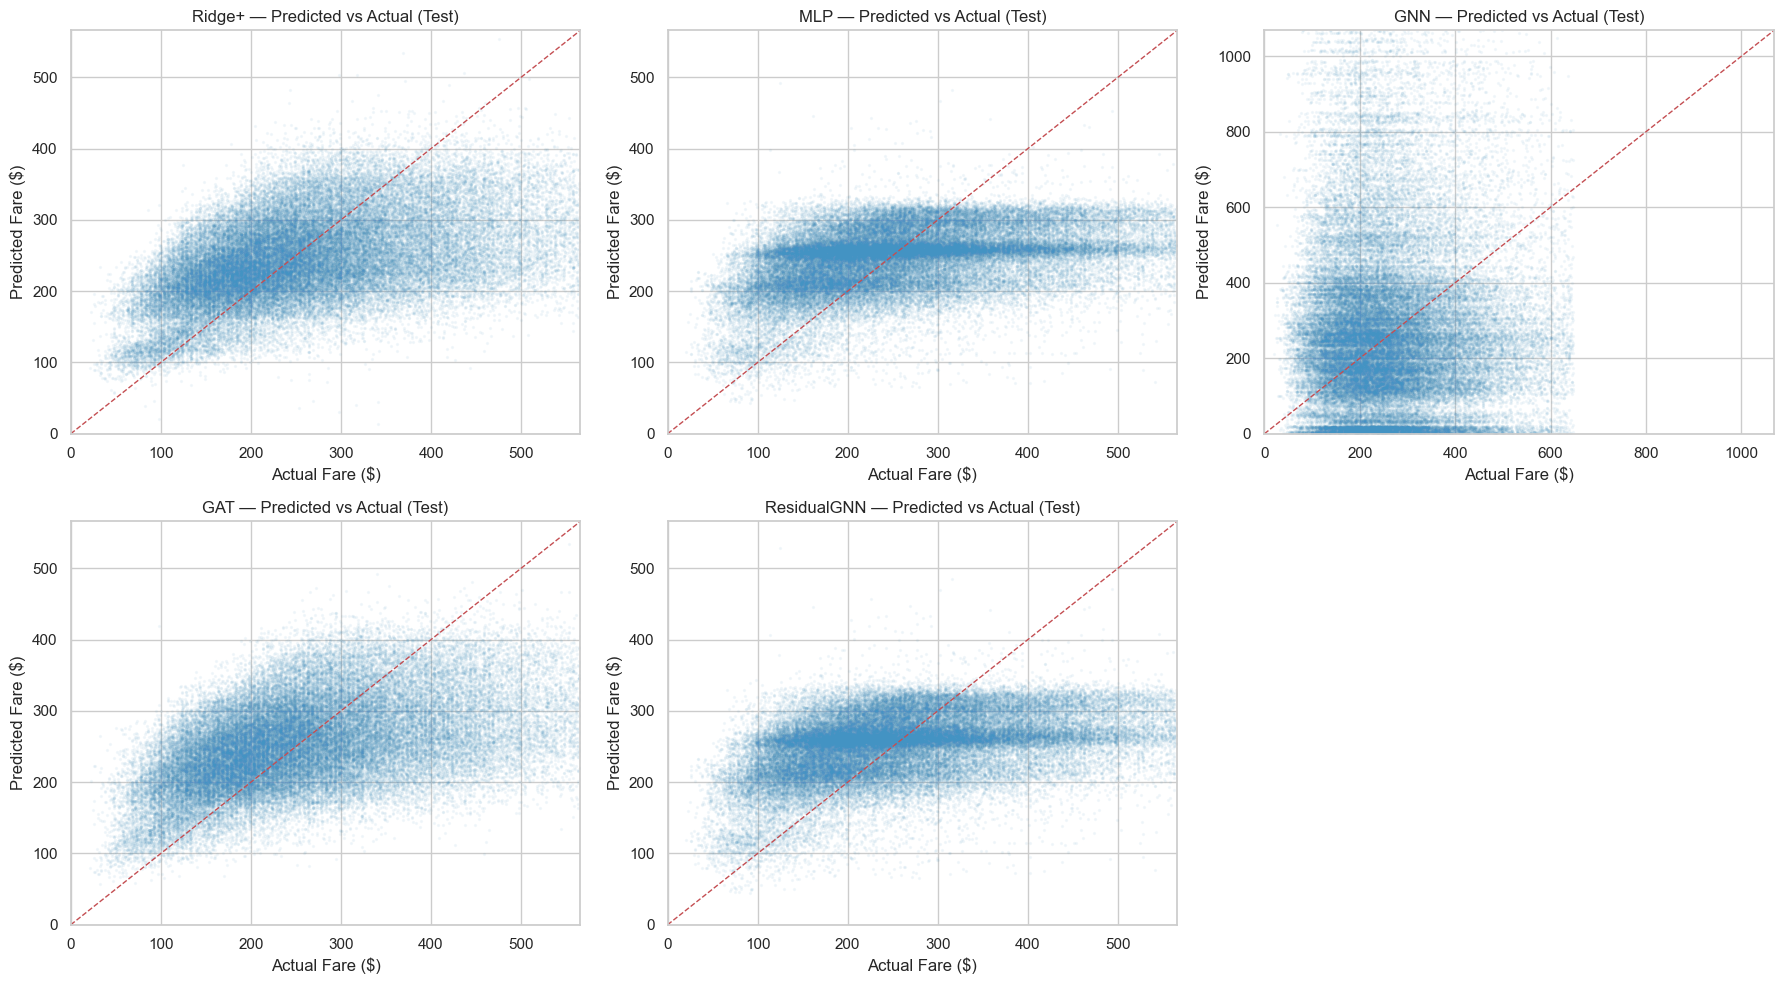

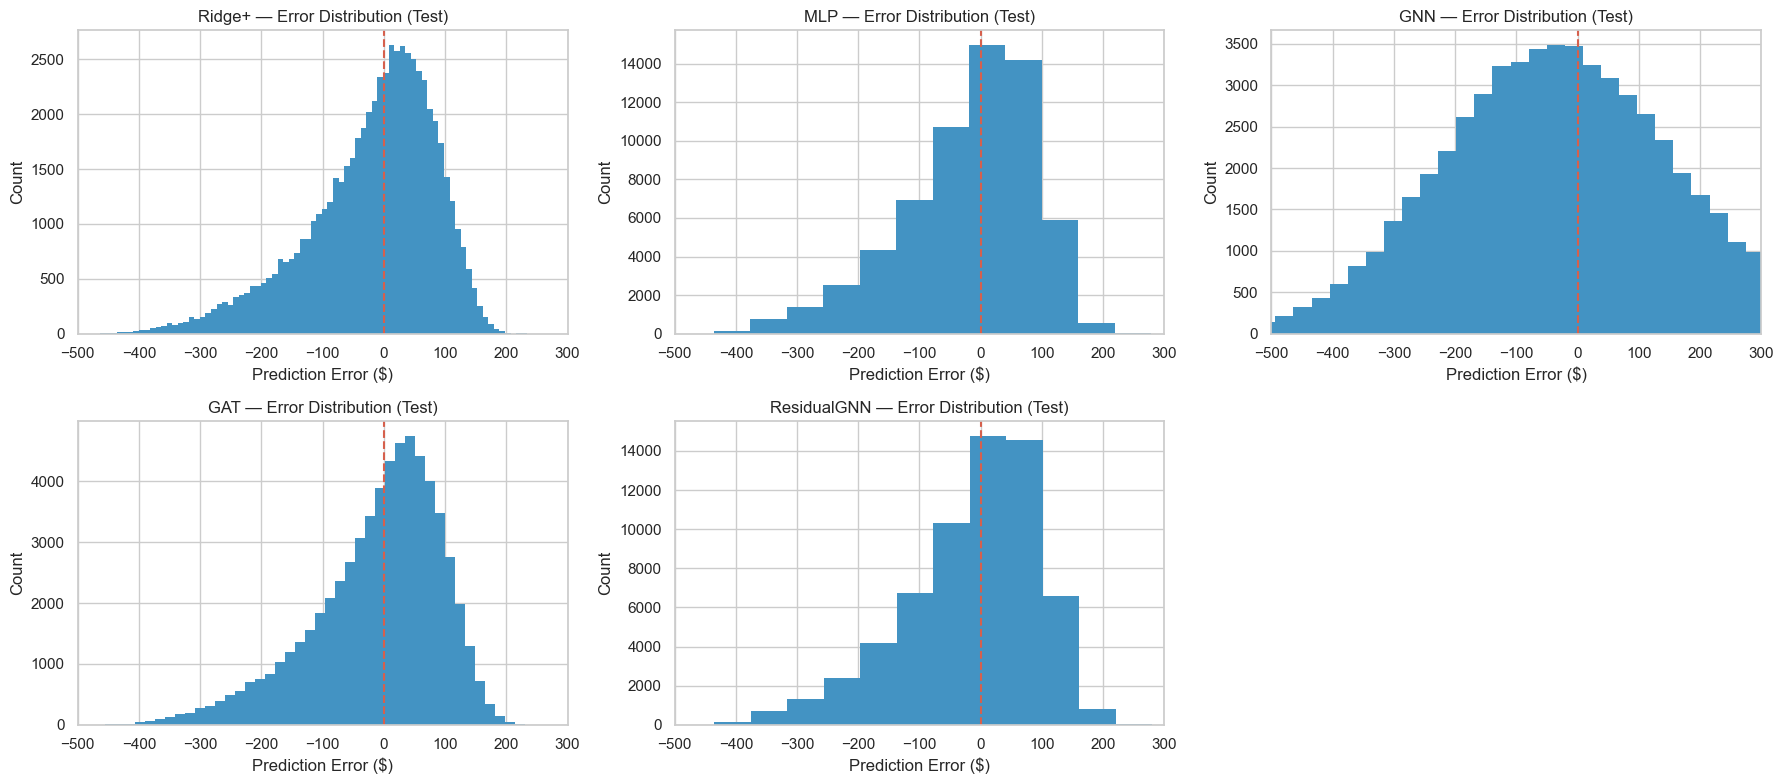


Median absolute error (test):
  Ridge+          $63.8
  MLP             $67.5
  GNN             $147.2
  GAT             $65.8
  ResidualGNN     $69.2


In [64]:
model.eval()
gat_model.eval()
res_model.eval()
with torch.no_grad():
    pred_log     = model(x_d, ei_d, ea_d, cids_d).cpu().numpy()
    gat_pred_log = gat_model(x_d, ei_d, ea_d, cids_d).cpu().numpy()
    res_pred_log = res_model(x_d, ei_d, ea_d, cids_d, mlp_pred_t).cpu().numpy()

y_np_all = y_d.cpu().numpy()

val_np   = val_idx.cpu().numpy()
test_np  = test_idx.cpu().numpy()
gnn_val  = eval_dollars(y_np_all[val_np],  pred_log[val_np])
gnn_test = eval_dollars(y_np_all[test_np], pred_log[test_np])
gat_val  = eval_dollars(y_np_all[val_np],  gat_pred_log[val_np])
gat_test = eval_dollars(y_np_all[test_np], gat_pred_log[test_np])
res_val  = eval_dollars(y_np_all[val_np],  res_pred_log[val_np])
res_test = eval_dollars(y_np_all[test_np], res_pred_log[test_np])

# ── Summary Table ─────────────────────────────────────────────────────────────
print("=" * 61)
print(f"{'Model':<15} {'Split':<6} {'RMSE ($)':>9} {'MAE ($)':>9} {'R²':>7}")
print("-" * 61)
for label, rv, rt in [
    ('Ridge+',      (rmse_v,     mae_v,     r2_v),     (rmse_t,     mae_t,     r2_t)),
    ('MLP',         (mlp_rmse_v, mlp_mae_v, mlp_r2_v), (mlp_rmse_t, mlp_mae_t, mlp_r2_t)),
    ('GNN',         gnn_val,                            gnn_test),
    ('GAT',         gat_val,                            gat_test),
    ('ResidualGNN', res_val,                            res_test),
]:
    rmse_rv, mae_rv, r2_rv = rv
    rmse_rt, mae_rt, r2_rt = rt
    print(f"{label:<15} {'Val':<6} {rmse_rv:>8.1f}  {mae_rv:>8.1f}  {r2_rv:>6.3f}")
    print(f"{label:<15} {'Test':<6} {rmse_rt:>8.1f}  {mae_rt:>8.1f}  {r2_rt:>6.3f}")
    print("-" * 61)

# ── Predicted vs Actual (Test) — all 5 models ─────────────────────────────────
y_true_test = np.exp(y_np_all[test_np])
preds_test = {
    'Ridge+':      bl_test,
    'MLP':         mlp_test_pred,
    'GNN':         pred_log[test_np],
    'GAT':         gat_pred_log[test_np],
    'ResidualGNN': res_pred_log[test_np],
}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, (label, y_pred_log) in zip(axes.flat, preds_test.items()):
    y_pred = np.exp(y_pred_log)
    ax.scatter(y_true_test, y_pred, alpha=0.05, s=2, color=BLUE)
    lim = np.percentile(np.concatenate([y_true_test, y_pred]), 99)
    ax.plot([0, lim], [0, lim], 'r--', linewidth=1)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Actual Fare ($)'); ax.set_ylabel('Predicted Fare ($)')
    ax.set_title(f'{label} — Predicted vs Actual (Test)')
axes.flat[-1].set_visible(False)
plt.tight_layout(); plt.show()

# ── Error Distribution (Test) ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for ax, (label, y_pred_log) in zip(axes.flat, preds_test.items()):
    errors = np.exp(y_pred_log) - y_true_test
    ax.hist(errors, bins=80, color=BLUE, edgecolor='none')
    ax.axvline(0, color='#d6604d', linestyle='--', linewidth=1.5)
    ax.set_xlim(-500, 300)
    ax.set_xlabel('Prediction Error ($)'); ax.set_ylabel('Count')
    ax.set_title(f'{label} — Error Distribution (Test)')
axes.flat[-1].set_visible(False)
plt.tight_layout(); plt.show()

print("\nMedian absolute error (test):")
for label, y_pred_log in preds_test.items():
    med = np.median(np.abs(np.exp(y_pred_log) - y_true_test))
    print(f"  {label:<15} ${med:.1f}")